# Welcome to SQUAT

In this tutorial, you will....



# Prepare virtual environment

To install packages into this project's vitual environment:

From terminal: in your terminal, navigate to the project's directory, and type `source /.venv/bin/activate`. This command goes to the directory `/.venv/bin` and runs the script called `activate`. Now your terminal looks something like "(.venv) adroster@MV42JGWLPD SQUAT_demo % ".

Now you can install packages with the typical `pip3 install [package name]`. We have prepared all the packages you need in the `requirements.txt` file in this directory. To install all of them, run `pip3 install -r requirements.txt`

When you're done working on this project, deactivate the environment from terminal with the command `deactivate`.

This is all true for MacOS (and probably Linux) but may be slightly different commands for Windows OS.



In [1]:
from idlelib.configdialog import changes

import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import pandas as pd

# Import useful functions

In [2]:
sys.path.append('Libraries')
# from parity_timestream import *
from squat_freqscan_fitter import *
from qubit_color_dict import qubit_colors
from squat_simulator import *
from VNA_import_funcs import unwrap_phases, series_list_to_elapsed_time, read_file


# Part 1: understanding SQUAT dynamics

In this section we will...


In [17]:
# Import a single SQUAT fscan data file, convert to linear complex
fn = "20260609_012659_Waymar2Q1.npz"

infile = read_file("./datafiles", fn)
phases, _ = unwrap_phases(infile, verbose=False)

freqs = infile['freqs']
qubit = infile['device'] + infile['qubit']
series = infile['series']

# - convert dB amplitude + phase -> linear complex S21
S21 = 10 ** (infile['amps'] / 20) * np.exp(1j * phases)

In [20]:
# Plot squat trace

def plot_vna_scan(freqs, s21, metadata=None, plot_title=None,
                  amp_db=True, savepath=None):
    """
    Plot a VNA frequency scan: amplitude vs freq, phase vs freq, and the
    IQ circle.

    Parameters
    ----------
    freqs : np.ndarray
        Frequency array in Hz.
    s21 : np.ndarray (complex)
        Complex transmission data.
    metadata : dict or None
        Optional metadata dict (from read_vna_npz) used to auto-build a title.
    plot_title : str or None
        Explicit title; overrides the metadata-derived one.
    amp_db : bool
        If True, plot amplitude in dB (20*log10|S21|); else linear magnitude.
    savepath : str or None
        If given, saves the figure to this path.

    Returns
    -------
    fig, axes
    """
    freqs_ghz = freqs / 1e9
    amp = np.abs(s21)
    amp_plot = 20 * np.log10(amp) if amp_db else amp
    phase = np.angle(s21)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    # - amplitude vs frequency
    axes[0].plot(freqs_ghz, amp_plot, color='steelblue', lw=1)
    axes[0].set_xlabel('Frequency (GHz)')
    axes[0].set_ylabel('|S21| (dB)' if amp_db else '|S21| (linear)')
    axes[0].set_title('Amplitude')

    # - phase vs frequency
    axes[1].plot(freqs_ghz, phase, color='seagreen', lw=1)
    axes[1].set_xlabel('Frequency (GHz)')
    axes[1].set_ylabel('Phase (rad)')
    axes[1].set_title('Phase')

    # - IQ circle
    axes[2].plot(s21.real, s21.imag, color='indianred', lw=1)
    axes[2].set_xlabel('I')
    axes[2].set_ylabel('Q')
    axes[2].set_title('IQ circle')
    axes[2].set_aspect('equal')

    # - title from metadata if available
    if plot_title is None and metadata is not None:
        dev = f"{metadata.get('device', '')}{metadata.get('qubit', '')}"
        ser = metadata.get('series', '')
        pwr = metadata.get('vna_power', 'N/A')
        plot_title = f"{ser}  {dev}  VNA power = {pwr} dBm"
    if plot_title:
        fig.suptitle(plot_title)

    plt.tight_layout()

    if savepath is not None:
        plt.savefig(savepath)

    return fig, axes

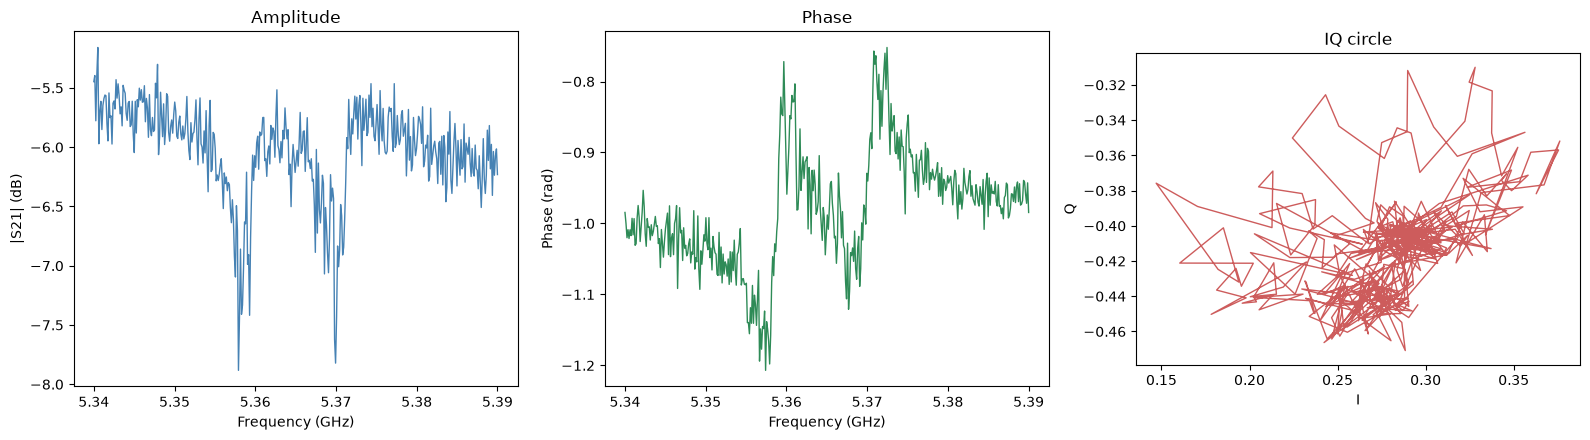

In [25]:
fig, axes = plot_vna_scan(freqs, S21, metadata=None, plot_title=None, amp_db=True, savepath=None)
plt.show()

### SQUAT fit equation

We are fitting to the function:

$$
S_{21}(\Delta) = 1 - \frac{\Gamma_c}{2\gamma}\frac{1-i\Delta/\gamma}{1+(\Delta/\gamma)^2+(\Omega^2/\gamma\Gamma_r)}
$$

note that this function is complex.

* $\Delta$ [Hz] is the detuning (angular frequency difference between qubit frequency and VNA tone).
* $\gamma$ [Hz] is total dephasing rate of the qubit. $\gamma = \frac{1}{2}(\Gamma_c+\Gamma_\ell)+\Gamma_\phi$.
* $\Gamma_r$ [Hz] is the total radiative decay rate. We have $\Gamma_r = \Gamma_c+\Gamma_\ell$.
* $\Gamma_c$ [Hz] is the radiative decay to the feedline. This provides the measured signal.
* $\Gamma_\ell$ [Hz] is the radiative decay rate to all other loss channels
* $\Gamma_\phi$ [Hz] is the dephasing rate, accounting for phase noise (like jitter of the qubit state in the Bloch spere)
* $\Omega$ [Hz] is the Rabi oscillation rate. We drive the qubit at this rate. It is related to the drive power parameter $\Gamma_n = \Omega^2/2\Gamma_r$

![](./images/gammas_doodle.png)

Fit successful for Gl=0 fit doubleres; 20260609_012659


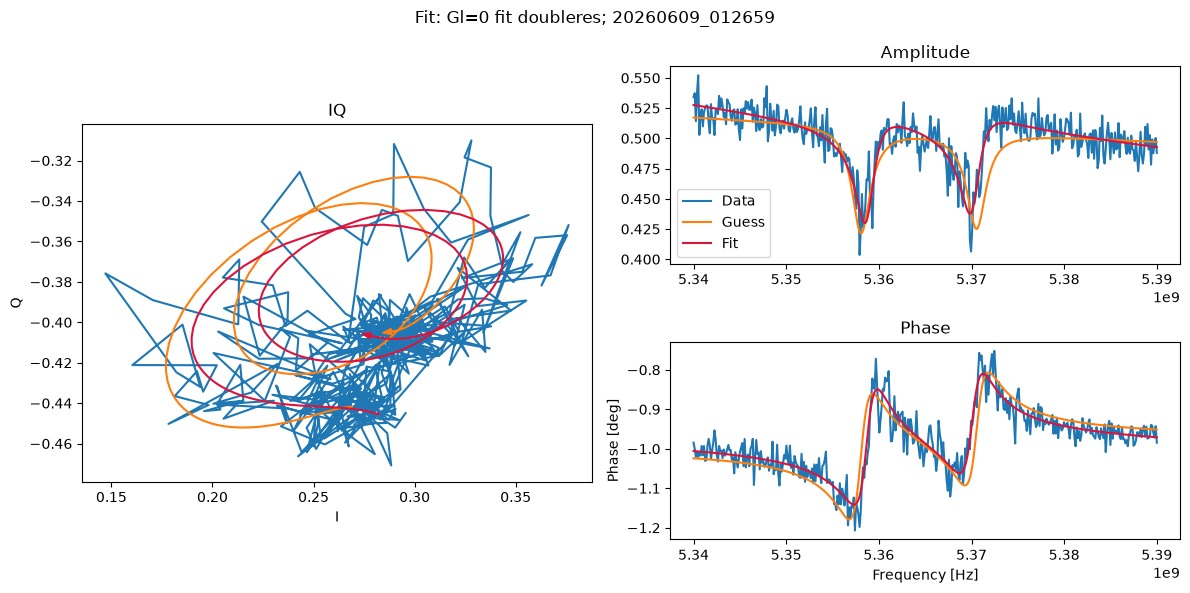

Fit successful for NonGl=0 fit doubleres; 20260609_012659


In [18]:
# Fit the single trace

trace = squat_S21_resfit(freqs, S21,
                         identifier=series,
                         force_doubleres=False)
trace.fit(plot_NonGl0=False, plot_Gl0=True, verbose=False)

fit_results = trace.NonGl0_fit_results
fit_uncs = trace.NonGl0_fit_result_uncs

# Part 2: manipulating SMuRF-like IQ data, searching for an event in the data

In this section, you will....

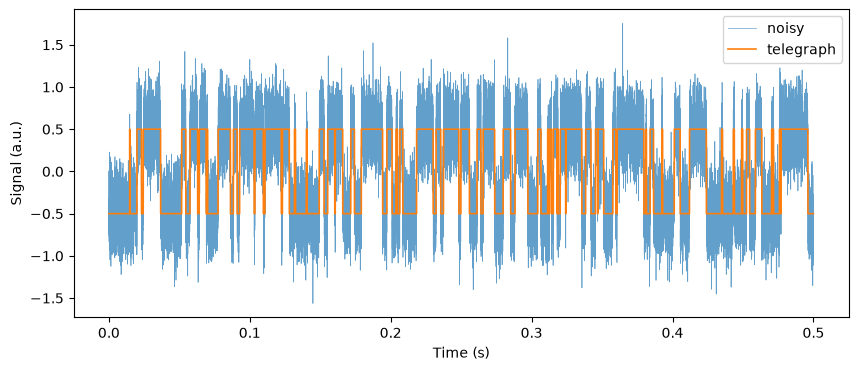

In [5]:
# 0.5 s of data, 50 kHz sampling, 200 Hz switching, SNR = 4
t, data, clean = generate_squat_data(
    duration=0.5,
    sampling_rate=50_000,
    switching_rate=200,
    snr=4.0,
    seed=42,
)

plt.figure(figsize=(10, 4))
plt.plot(t, data, lw=0.5, alpha=0.7, label="noisy")
plt.plot(t, clean, lw=1.2, label="telegraph")
plt.xlabel("Time (s)")
plt.ylabel("Signal (a.u.)")
plt.legend()
plt.show()

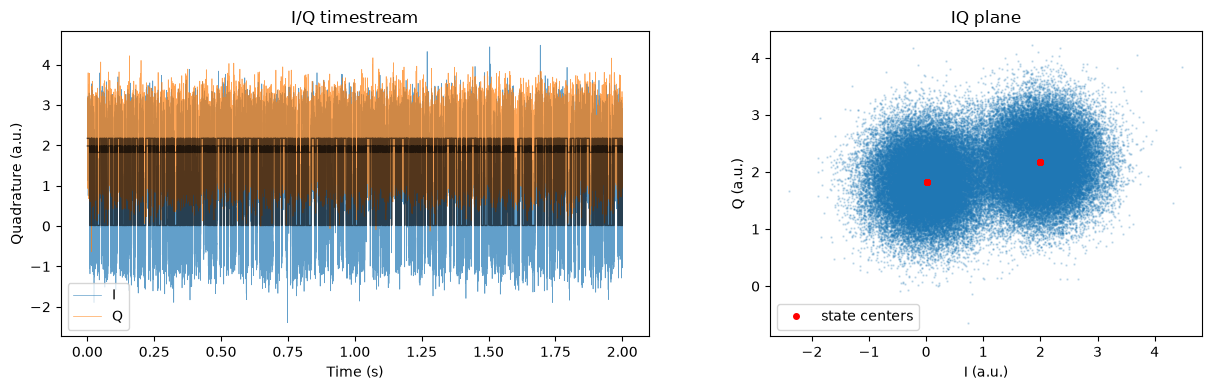

In [6]:
# 0.2 s of data, 50 kHz sampling, 300 Hz switching.
# Two IQ blobs separated by 2.0 units along 30 degrees, SNR = 4.
t, iq, clean = generate_squat_iq_data(
    duration=2,
    sampling_rate=50_000,
    switching_rate=300,
    separation=2.0,
    angle=np.deg2rad(10),
    dc_offset=(1, 2),
    snr=4.0,
    seed=42,
)

I, Q = iq.real, iq.imag

fig, (ax_t, ax_iq) = plt.subplots(1, 2, figsize=(13, 4))

# Time-domain view: I and Q quadratures vs time.
ax_t.plot(t, I, lw=0.5, alpha=0.7, label="I")
ax_t.plot(t, Q, lw=0.5, alpha=0.7, label="Q")
ax_t.plot(t, clean.real, "k", lw=1.0, alpha=0.6)
ax_t.plot(t, clean.imag, "k", lw=1.0, alpha=0.6)
ax_t.set_xlabel("Time (s)")
ax_t.set_ylabel("Quadrature (a.u.)")
ax_t.set_title("I/Q timestream")
ax_t.legend()

# IQ-plane view: the two "blobs" should be visible.
ax_iq.plot(I, Q, ".", ms=1.5, alpha=0.2)
ax_iq.plot(clean.real, clean.imag, "r.", ms=8, label="state centers")
ax_iq.set_xlabel("I (a.u.)")
ax_iq.set_ylabel("Q (a.u.)")
ax_iq.set_title("IQ plane")
ax_iq.set_aspect("equal")
ax_iq.legend()

plt.tight_layout()
plt.show()

In [7]:
# Save the fake data to csv
df = pd.DataFrame({"time (ms)": t * 1e3, "IQ": iq})
df.to_csv("datafiles/squat_iq_data.csv", index=False)

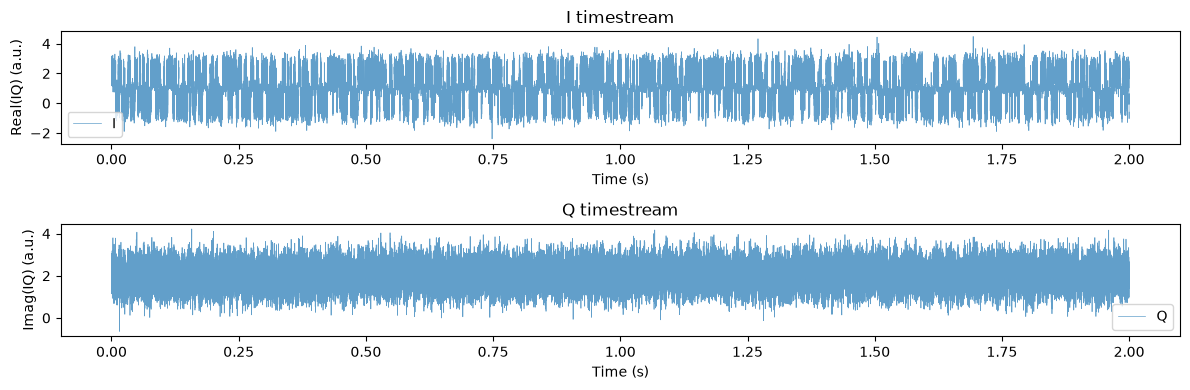

In [8]:
fig, (ax_i, ax_q) = plt.subplots(2, 1, figsize=(12, 4))

# Time-domain view: I quadrature vs time.
ax_i.plot(t, I, lw=0.5, alpha=0.7, label="I")
# ax_i.plot(t, clean.real, "k", lw=1.0, alpha=0.6)
ax_i.set_xlabel("Time (s)")
ax_i.set_ylabel("Real(IQ) (a.u.)")
ax_i.set_title("I timestream")
ax_i.legend()

# Time-domain view: Q quadrature vs time.
ax_q.plot(t, Q, lw=0.5, alpha=0.7, label="Q")
# ax_q.plot(t, clean.imag, "k", lw=1.0, alpha=0.6)
ax_q.set_xlabel("Time (s)")
ax_q.set_ylabel("Imag(IQ) (a.u.)")
ax_q.set_title("Q timestream")
ax_q.legend()

plt.tight_layout()
plt.show()

### Filter the data for better SNR

In [9]:
## Butterworth filter

# Find the optimal readout axis in IQ space

We see from the above data that most of the signal is in the I quadrature. Equivalently, the two blobs in IQ space are aligned mostly along the I-axis. For optimal readout fidelity, we'd like a linear combination of I and Q, and in particular the linear combination that is along the axis in IQ space that connects the center of the two blobs (see image)

![](./images/IQ_blobs_readout.png)

Your task here is to
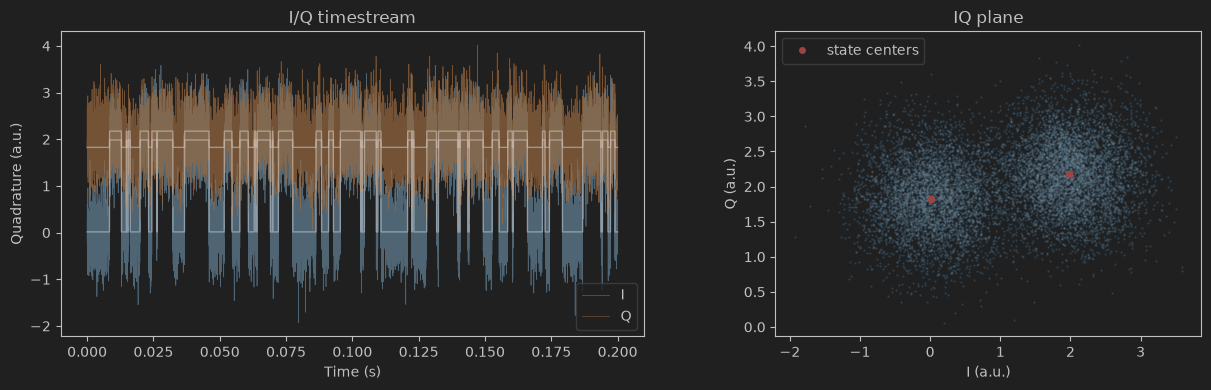

In [10]:
### need to make function similar to calc_iq_rot but outside the parity timestream class architecture

# PSD this telegraph signal and fit a Lorentzian to extract switching rate

In [11]:
#### Also take calc_psd out of the parity_timestream class

In [12]:
from parity_timestream_funcs import *

In [13]:
# 1. Load the fake data from CSV
times_ms, iq = load_iq_csv("datafiles/squat_iq_data.csv")
i_raw, q_raw = iq.real, iq.imag

# 2. Rotate so the max-separation axis lies along I_rot
i_rot, q_rot, raw_gmm = compute_iq_rot(i_raw, q_raw)

# 3. PSD directly along the max-separation axis (I_rot)
psd_freqs, psd_yvals, tel_cen, tel_sep = calc_psd(i_rot, times_ms)

# 4. Fit a Lorentzian
fit_params = fit_psd(psd_freqs, psd_yvals, times_ms,
                     fit_to_corrected_function=True)

print("Gamma_p =", fit_params['psd_corr_fit_Gamma_p'], "Hz")

Gamma_p = 50.46798735783406 Hz


Telegraph centerline: -0.05027570697229408  separation: 2.0128362536735054
Gamma_p = 50.46947390800951 Hz


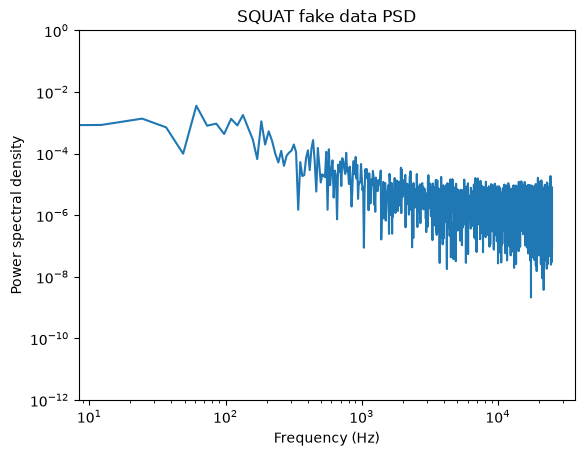

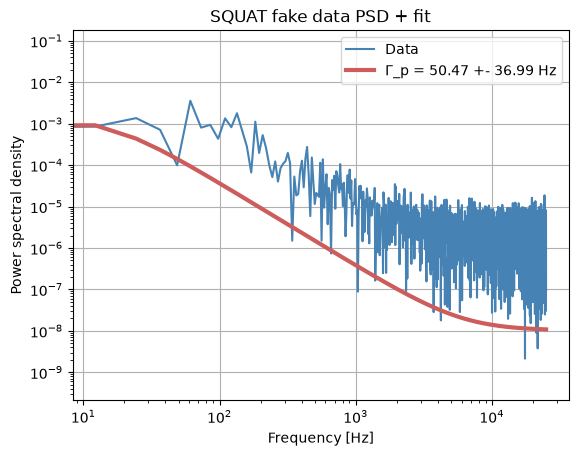

In [14]:
# 1. Load the fake data from CSV
times_ms, iq = load_iq_csv("datafiles/squat_iq_data.csv")
i_raw, q_raw = iq.real, iq.imag

# 2. Rotate so the max-separation axis lies along I_rot
i_rot, q_rot, raw_gmm = compute_iq_rot(i_raw, q_raw)

# 3. PSD directly along the max-separation axis (I_rot)
psd_freqs, psd_yvals, tel_cen, tel_sep = calc_psd(i_rot, times_ms)

# 4. Fit a Lorentzian to the PSD
fit_params = fit_psd(psd_freqs, psd_yvals, times_ms,
                     fit_to_corrected_function=True)

print("Telegraph centerline:", tel_cen, " separation:", tel_sep)
if fit_params is not None:
    print("Gamma_p =", fit_params['psd_corr_fit_Gamma_p'], "Hz")

# 5a. Plot the raw PSD
fig1, ax1 = plot_psd(psd_freqs, psd_yvals,
                     plot_title="SQUAT fake data PSD",
                     savepath="plots/fake_psd.png")

# 5b. Plot the PSD with the Lorentzian fit overlaid
fig2, ax2 = plot_psd_fit(psd_freqs, psd_yvals, fit_params, times_ms,
                         plot_title="SQUAT fake data PSD + fit",
                         plot_corrected_fit=True,
                         plot_standard_fit=False,
                         savepath="plots/fake_psd_fit.png")

plt.show()

You'll notice that the fit is not the best. Generally we like to take several timestream data sets, PSD each of them, and average the PSDs. Equivalently, we can chunk the PSD into smaller segments (~0.1 s) PSD each segment, and average the PSDs.

Gamma_p = 331.5377121622913 Hz


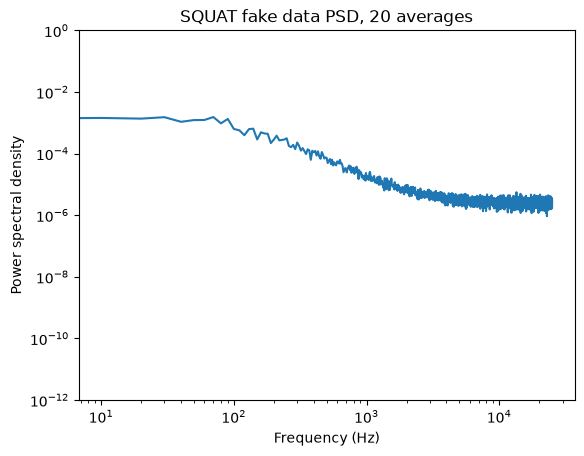

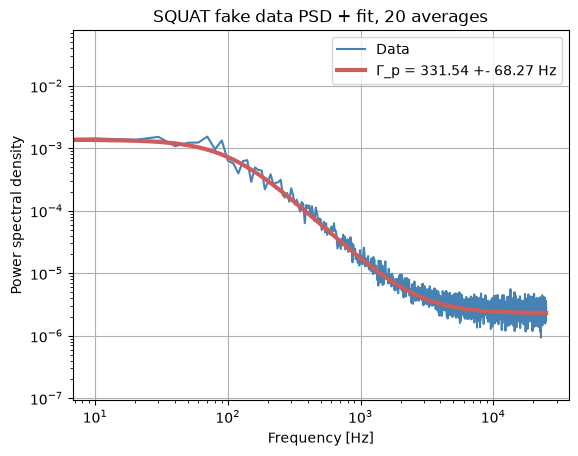

In [15]:
# 2 s of data, 50 kHz sampling, 300 Hz switching.
# Two IQ blobs separated by 2.0 units along 10 degrees, SNR = 4.
# Let's do this 20 times, take PSDs, and average the PSDs.

times_ms, iq = load_iq_csv("datafiles/squat_iq_data.csv")

n_chunks = 20
n_times = len(times_ms)
nfft = int(np.floor(n_times / n_chunks))

psd_yval_array = np.zeros((n_chunks, int(nfft/2 + 1)))

for chunk in np.arange(n_chunks):
    times_ms_chunked = times_ms[chunk * nfft:(chunk + 1) * nfft]
    iq_chunked = iq[nfft*chunk:nfft*(chunk+1)]

    i_raw, q_raw = iq_chunked.real, iq_chunked.imag

    # 2. Rotate so the max-separation axis lies along I_rot
    i_rot, q_rot, raw_gmm = compute_iq_rot(i_raw, q_raw)

    # 3. PSD directly along the max-separation axis (I_rot)
    psd_freqs, psd_yvals, tel_cen, tel_sep = calc_psd(i_rot, times_ms_chunked, nfft = nfft)

    psd_yval_array[chunk] = psd_yvals

# 4. Average the PSDs

psd_avg = np.mean(psd_yval_array, axis=0)

# 5. Fit a Lorentzian to the PSD
fit_params = fit_psd(psd_freqs, psd_avg, times_ms_chunked,
                     fit_to_corrected_function=True)

if fit_params is not None:
    print("Gamma_p =", fit_params['psd_corr_fit_Gamma_p'], "Hz")

# 6a. Plot the raw PSD
fig1, ax1 = plot_psd(psd_freqs, psd_avg,
                     plot_title=f"SQUAT fake data PSD, {n_chunks} averages",
                     savepath="plots/fake_psd.png")

# 6b. Plot the PSD with the Lorentzian fit overlaid
fig2, ax2 = plot_psd_fit(psd_freqs, psd_avg, fit_params, times_ms,
                         plot_title=f"SQUAT fake data PSD + fit, {n_chunks} averages",
                         plot_corrected_fit=True,
                         plot_standard_fit=False,
                         savepath="plots/fake_psd_fit.png")


How would this change with a low tunneling rate, like 5 Hz? How would your data taking and data processing need to change?

# Extra time?

Let's play with filtering

Let's look for an event

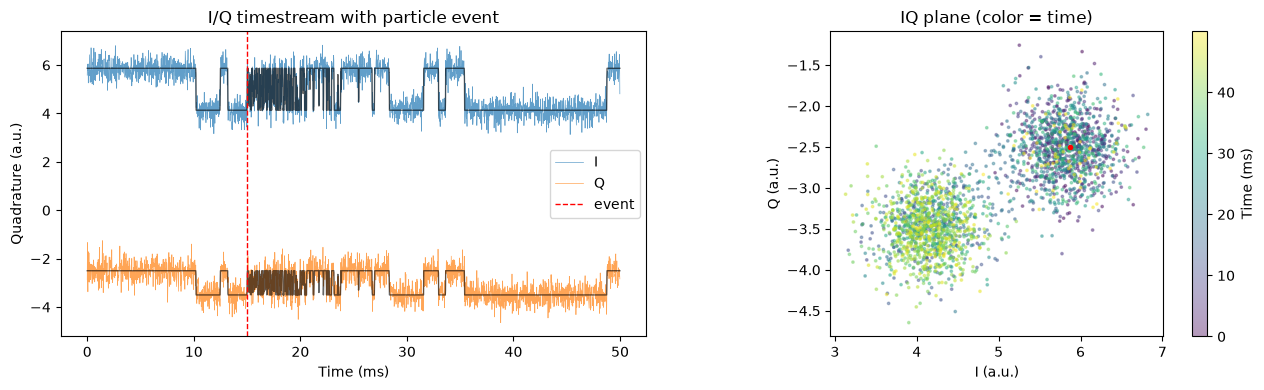

In [16]:
# 50 ms of data at 50 kHz. Baseline switching 200 Hz, particle hits at 15 ms,
# event peaks at 100 kHz and decays with tau = 2.5 ms (~10 ms visible event).
t, iq, clean = generate_squat_iq_data_with_event(
    duration=0.05,
    sampling_rate=50_000,
    baseline_switching_rate=200,
    event_time=0.015,
    event_peak_rate=100e3,
    event_tau=2.5e-3,
    separation=2.0,
    angle=np.deg2rad(30),
    dc_offset=(5.0, -3.0),
    snr=6.0,
    seed=42,
)

df = pd.DataFrame({"time (ms)": t, "IQ": iq})
df.to_csv("datafiles/squat_iq_with_event_data.csv", index=False)

I, Q = iq.real, iq.imag

fig, (ax_t, ax_iq) = plt.subplots(1, 2, figsize=(13, 4))

# Time domain: watch the signal collapse toward the midpoint during the event.
ax_t.plot(t * 1e3, I, lw=0.5, alpha=0.7, label="I")
ax_t.plot(t * 1e3, Q, lw=0.5, alpha=0.7, label="Q")
ax_t.plot(t * 1e3, clean.real, "k", lw=1.0, alpha=0.6)
ax_t.plot(t * 1e3, clean.imag, "k", lw=1.0, alpha=0.6)
ax_t.axvline(15, color="r", ls="--", lw=1, label="event")
ax_t.set_xlabel("Time (ms)")
ax_t.set_ylabel("Quadrature (a.u.)")
ax_t.set_title("I/Q timestream with particle event")
ax_t.legend()

# IQ plane: during the event, points cluster near the midpoint of the blobs.
sc = ax_iq.scatter(I, Q, c=t * 1e3, s=3, alpha=0.4, cmap="viridis")
ax_iq.plot([z.real for z in (clean[0],)], [z.imag for z in (clean[0],)], "r.")
ax_iq.set_xlabel("I (a.u.)")
ax_iq.set_ylabel("Q (a.u.)")
ax_iq.set_title("IQ plane (color = time)")
ax_iq.set_aspect("equal")
plt.colorbar(sc, ax=ax_iq, label="Time (ms)")

plt.tight_layout()
plt.show()

### Now chunk the data into time bins of width $\Delta t$, PSD those time bins, fit to each PSD, and plot the rate vs time.